Etapas obrigatórias:
Carregar a base Varejo.csv com pandas e mostrar: número de registros, colunas e tipos de dados. FEITO

Verificar e reportar ao menos dois problemas básicos: valores nulos por coluna, duplicatas e possíveis inconsistências (ex.: datas inválidas ou categorias vazias).
RESPOSTA: 3 Colunas vazias, tipo de categoria ND = NULO

Fazer as três etapas de limpeza mínima necessária: remover ou imputar nulos (explique a escolha), eliminar duplicatas relevantes e ajustar tipos de dados (ex.: converter coluna DATA para datetime).
RESPOSTA: Realizei a retirada das 3 colunas (Unnamed) e a retirada da categoria ND para não atrapalhar a visualização do grafico de Histograma. troca de DATA para DATATIME foi feita


Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem).
Explorar padrões de agrupamento com pelo menos dois agrupamentos (por exemplo: gênero com mais vendas, compras), usando groupby() ou pivot_table().
Produzir um pequeno bloco de conclusões (3–6 tópicos) com os principais insights obtidos e possíveis problemas remanescentes na base.

Requisitos técnicos mínimos:
O script deve ser executável em VsCode ou Google Colab (arquivo .py).
Usar pandas; outras bibliotecas são opcionais (NumPy, Matplotlib, Seaborn).


In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#---- LEITURA DO ARQUIVO CSV ----
df = pd.read_csv("Base_Varejo.csv", sep=";", encoding="cp1252", decimal=",")
# Converte a coluna de data de admissão para o tipo datetime
df["DATA"] = pd.to_datetime(
    df["DATA"],
    format="%d/%m/%Y",
    errors="coerce"
)


#---- EXIBIÇÃO DAS 5 PRIMEIRAS LINHAS e 5 ultimas LINHAS DO DATAFRAME ----
df.head(5)
#df.tail(5)

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


In [38]:
print(f"DataFrame possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
print('\n' + '='*50)
print(f"Nomes das Colunas: ")
print(df.columns)
print('\n' + '='*50)
print(f"Tipos de Dados: ")
print(df.dtypes)

DataFrame possui 830000 linhas e 14 colunas.

Nomes das Colunas: 
Index(['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG',
       'PR_ID', 'PR_CAT', 'PR_NOME', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13'],
      dtype='str')

Tipos de Dados: 
DATA               str
CO_ID            int64
CL_ID            int64
CL_GENERO          str
CL_EC            int64
CL_FHL           int64
CL_SEG             str
PR_ID            int64
PR_CAT             str
PR_NOME            str
Unnamed: 10    float64
Unnamed: 11    float64
Unnamed: 12    float64
Unnamed: 13    float64
dtype: object


In [71]:

# Remove todas as colunas cujo nome começa com 'Unnamed'
df = df.loc[:, ~df.columns.str.contains('^Unnamed')] 

print(df.info()) # para verificar o número de valores não nulos em cada coluna, e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   DATA       830000 non-null  str  
 1   CO_ID      830000 non-null  int64
 2   CL_ID      830000 non-null  int64
 3   CL_GENERO  830000 non-null  str  
 4   CL_EC      830000 non-null  int64
 5   CL_FHL     830000 non-null  int64
 6   CL_SEG     830000 non-null  str  
 7   PR_ID      830000 non-null  int64
 8   PR_CAT     826350 non-null  str  
 9   PR_NOME    830000 non-null  str  
dtypes: int64(5), str(5)
memory usage: 63.3 MB
None


In [72]:
print(df.describe()) # para obter uma visão geral das colunas numéricas, incluindo contagem, média, desvio padrão, valores mínimos e máximos, e os quartis.
# nao aparece haver colunas numéricas, então o resultado do describe() é vazio.

              CO_ID          CL_ID          CL_EC        CL_FHL          PR_ID
count  830000.00000  830000.000000  830000.000000  830000.00000  830000.000000
mean   460045.08989     499.595204       2.596911       1.14654     115.051855
std    265465.24754     287.568253       1.170599       1.41696      66.129241
min      1000.00000       1.000000       1.000000       0.00000       1.000000
25%    233117.00000     254.000000       2.000000       0.00000      58.000000
50%    456517.00000     498.000000       3.000000       0.00000     115.000000
75%    690132.00000     746.000000       4.000000       2.00000     172.000000
max    919822.00000    1000.000000       5.000000       4.00000     229.000000


In [ ]:
print('Valores únicos por coluna:')
print(df.nunique())

# para verificar os valores únicos de cada coluna, e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).
#df[["DATA","CO_ID","CL_ID","CL_GENERO","CL_EC","CL_FHL","CL_SEG","PR_ID","PR_CAT","PR_NOME"]].head(10) 
df["PR_CAT"].value_counts() # para verificar os valores únicos da coluna "PR_CAT", e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).



Valores únicos por coluna:
DATA           333
CO_ID        18471
CL_ID         1000
CL_GENERO        2
CL_EC            5
CL_FHL           5
CL_SEG           3
PR_ID          229
PR_CAT           6
PR_NOME        118
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   PR_CAT  826350 non-null  str  
dtypes: str(1)
memory usage: 6.3 MB


Agora realizar as visualizações


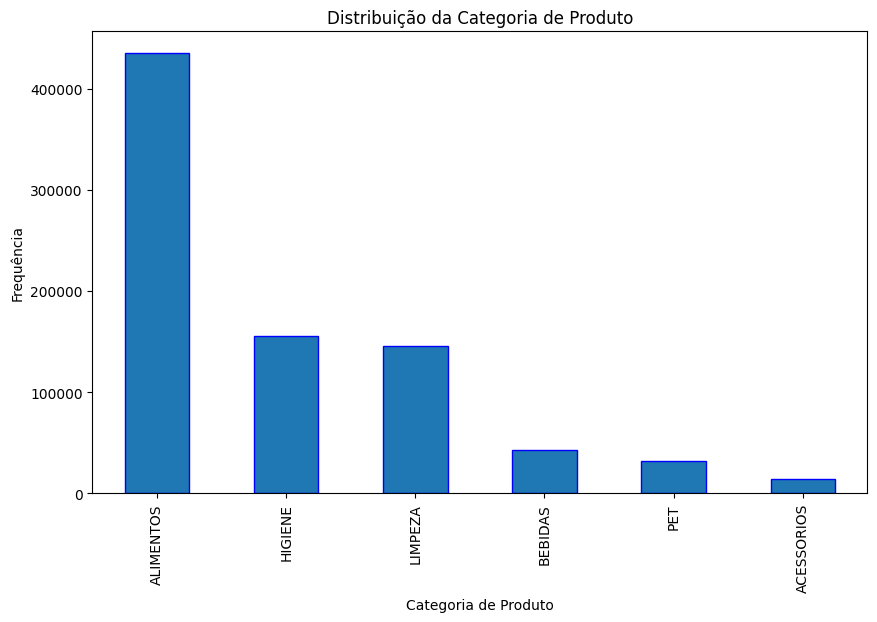

In [87]:
# Contagem das categorias
contagem = df["PR_CAT"].value_counts() # para contar a frequência de cada categoria na coluna "PR_CAT", e obter uma série com os valores únicos e suas respectivas contagens.

# Gráfico de barras
contagem.plot(kind="bar", figsize=(10,6), edgecolor="blue") # para criar um gráfico de barras com as contagens das categorias, e personalizar o tamanho da figura e a cor da borda das barras.
plt.title("Distribuição da Categoria de Produto")# para adicionar um título ao gráfico, e descrever o que ele representa.
plt.xlabel("Categoria de Produto")# para adicionar um rótulo ao eixo x, e descrever o que ele representa.
plt.ylabel("Frequência")# para adicionar um rótulo ao eixo y, e descrever o que ele representa.
plt.show()# para exibir o gráfico, e visualizar a distribuição das categorias de produto.


# DataFrame possui 830000 linhas e 14 colunas.
# 4 Colunas sem nome e sem valores ( consegui remover as colunas)
# 5 colunas Stings, 5 colunas Int, 4 colunas Float (sem nomes)
 clientes = 1000
 categoria de produtos 7 (1cvategoria e ND)
 118 tipos de produtos
 
 # import numpy as np para retirar a categoria ND do meu histograma 